## Imports

In [1]:
import sys
mypath = "/home/basia/Documents/spectroscopy/magnetstein"
sys.path.insert(0, mypath)
import numpy as np
import pandas as pd
import os
from masserstein import NMRSpectrum, estimate_proportions, estimate_proportions_in_time
import matplotlib.pyplot as plt
import pulp
import pickle
import time
from scipy.stats import cauchy
import math

## Scenario 1: with unique peaks

### Parameters

Set:

In [2]:
main_peak_position = 1.
small_peak_position = 4.
ground_truth_proportions = [0.9, 0.1]
scale = 0.03

Adjustable:

In [3]:
small_peak_proportion = np.arange(0.01, 1, 0.04)
common_kappa = np.arange(0.001, 1, 0.05)

### Library 

Set:

In [4]:
chemical_shift_axis = np.arange(0, 5, 0.001)

main_peak = cauchy.pdf(np.array(chemical_shift_axis), 
                                        loc = main_peak_position, 
                                        scale = scale)
small_peak = cauchy.pdf(np.array(chemical_shift_axis), 
                                        loc = small_peak_position, 
                                        scale = scale)

Adjustable:

In [5]:
def add_in_proportion(main_peak, small_peak, chemical_shift_axis, small_peak_proportion):
    
    component_0 = NMRSpectrum(confs = list(zip(chemical_shift_axis, main_peak)))
    component_0.normalize()
    
    component_1 = NMRSpectrum(confs = list(zip(chemical_shift_axis, small_peak)))
    component_1.normalize(small_peak_proportion / (1 + small_peak_proportion))
    component_1_intensities = np.array(component_0.confs)[:,1] + np.array(component_1.confs)[:,1]
    component_1 = NMRSpectrum(confs = list(zip(chemical_shift_axis, component_1_intensities)))
    component_1.normalize()
    
    return component_0, component_1

In [6]:
#NMRSpectrum.plot_all([component_0, component_1], profile=True)

### Mixture

In [7]:
def create_mixture(component_0, component_1, ground_truth_proportions):

    assert np.all(np.array(component_0.confs)[:,0] == np.array(component_1.confs)[:,0])
    chemical_shift_axis = np.array(component_0.confs)[:,0]
    
    component_0_intensities = np.array(component_0.confs)[:,1]
    component_1_intensities = np.array(component_1.confs)[:,1]
    mixture_intensities = ground_truth_proportions[0]*component_0_intensities + ground_truth_proportions[1]*component_1_intensities
    mixture = NMRSpectrum(confs=list(zip(chemical_shift_axis, mixture_intensities)))
    mixture.normalize()
    
    return mixture

### Estimation

In [8]:
abs_error_df = pd.DataFrame(index=1-small_peak_proportion, columns=common_kappa)

In [9]:
for sm in small_peak_proportion:
    for common_k in common_kappa:
        component_0, component_1 = add_in_proportion(main_peak, small_peak, chemical_shift_axis, sm)
        mixture = create_mixture(component_0, component_1, ground_truth_proportions)
        estimation = estimate_proportions(mixture, [component_0, component_1], what_to_compare='area', 
                                      solver=pulp.GUROBI(msg=False),
                                     MTD=common_k, MTD_th=common_k)
        abs_err = sum([abs(el-gt) for el, gt in zip(estimation['proportions'], ground_truth_proportions)])
        print(estimation['proportions'])
        abs_error_df.loc[1-sm, common_k] = abs_err

/home/basia/myvirtualenv/lib/python3.12/site-packages/pulp/pulp.py:1316: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


Set parameter Username
Academic license - for non-commercial use only - expires 2025-12-20
[np.float64(0.8999999999999987), np.float64(0.09999999999999987)]
[np.float64(0.8999999999999987), np.float64(0.09999999999999987)]
[np.float64(0.8999999999999987), np.float64(0.09999999999999987)]
[np.float64(0.8999999999999987), np.float64(0.09999999999999987)]
[np.float64(0.8999999999999987), np.float64(0.09999999999999987)]
[np.float64(0.8999999999999987), np.float64(0.09999999999999987)]
[np.float64(0.8999999999999987), np.float64(0.09999999999999987)]
[np.float64(0.8999999999999987), np.float64(0.09999999999999987)]
[np.float64(0.8999999999999987), np.float64(0.09999999999999987)]
[np.float64(0.8999999999999987), np.float64(0.09999999999999987)]
[np.float64(0.8999999999999987), np.float64(0.09999999999999987)]
[np.float64(0.8999999999999987), np.float64(0.09999999999999987)]
[np.float64(0.8999999999999987), np.float64(0.09999999999999987)]
[np.float64(0.8999999999999987), np.float64(0.09999

TypeError: type NoneType doesn't define __round__ method

In [ ]:
abs_error_df

Where are the errors???

## Scenario 2: without unique peaks

### Theory

**1. Properties of Lorentz distribution**

Let us start from describing the basic properties of the Lorentz distribution to understand the further reasoning.

Lorentz distribution (i.e. Cauchy distribution) has two parameters: $x_0$ (location, real) and $\gamma$ (shape, positive).

The formula for PDF is as follows:

$ p(x) = \frac{1}{\pi \gamma \Big[1 + (\frac{x-x_{0}}{\gamma})^2\Big]} $

And for CDF:

$ f(x) = \frac{1}{\pi} \text{arctan}\Big(\frac{x-x_0}{\gamma}\Big) + \frac{1}{2}$

Lorentz distribution is symmetric around $x_0$ which we can see from the formula for PDF.

**2. Our task**

We would like to simulate two lorentzian peaks (i.e. distributions) with some overlap. Let's say that the first distribution has the location parameter $x_0$ and cumulative distribution function $f_0$ and that the second distribution has the location parameter $x_1$ and cumulative distribution function $f_2$. Let's assume that they share the same scale parameter $\gamma$ and that $x_1 > x_0$, i.e. the second distribution is located on the right hand side of the first one.

We would like to be able to change the amount of overlap. Without the loss of generality, we can fix $x_0$ and change only $x_1$. Now, we would like to know how to change $x_1$ to obtain a specific proportion of overlap $P$. So, basically, we would like to get a formula for a function calculating $x_1$ from $P$ somehow.

**3. Solution**

First, let us notice that the point of intersection of the two PDFs is exactly in the middle between $x_0$ and $x_1$, i.e. in $x^{*}=\frac{x_0+x_1}{2}$. (This is due to symmetry of the Lorentz distribution, but can be also explicitly calculated).

To calculate the area of overlap, we need to add two areas: the first one is the area to the left of $x^{*}$ and, at the same time, below $p_1$ and the second one is the area to the right of $x^{*}$ and, at the same time, below $p_0$. From symmetry it is enough to calculate one of them and multiply it by 2.

The area to the right of $x^{*}$ and, at the same time, below $p_1$ is exactly the value of CDF in point $x^*$, i.e. $f_1(\frac{x_0+x_1}{2})$. So the formula for proportion of overlap $P$ as a function of $x_1$ is:

$P = 2 \cdot f_1(\frac{x_0+x_1}{2})$

Now, we need to use the explicit formula for Lorentz distribution's CDF:

$P = \frac{2}{\pi} \text{arctan}\Big(\frac{x_0-x_1}{2\gamma}\Big) + 1$

Now we need to transform this equation to get the formula for $x_1$ as a function of $P$:

$\frac{\pi}{2}(P-1)=\text{arctan}\Big(\frac{x_0-x_1}{2\gamma}\Big)$

$x_1 = -2 \gamma \cdot \text{tan}\Big[\frac{\pi}{2}(P-1) \Big] + x_0$

From trigonometric properties:

$x_1 = 2 \gamma \cdot \text{tan}\Big[\frac{\pi}{2}(1-P) \Big] + x_0$

This is the function that we've been seeking. Note that it makes sense, because for $P=1$ the value is $x_0$ and for $P=0$ is undefined, becuase it is impossible for the two Lorentzian peaks on the real number line to have no overlap.

### Parameters

Set:

In [118]:
first_peak_position = 2.5
scale = 0.03

Adjustable:

In [119]:
overlap_proportion = 0.98
ground_truth_proportions = [0.95, 0.05]
common_kappa = np.arange(0.001, 1, 0.05)

### Library

Set:

In [129]:
chemical_shift_axis = np.arange(0, 5, 0.001)

In [130]:
def create_first_peak(chemical_shift_axis, first_peak_position, scale):
    first_peak = cauchy.pdf(np.array(chemical_shift_axis), 
                                            loc = first_peak_position, 
                                            scale = scale)
    res = NMRSpectrum(confs=list(zip(chemical_shift_axis, first_peak)))
    res.normalize()
    return res

Adjustable:

In [131]:
def second_peak_location(overlap_proportion, first_peak_position, scale):
    return 2*scale*np.tan((math.pi*0.5)*(1-overlap_proportion)) + first_peak_position

In [132]:
def create_second_peak(overlap_proportion, first_peak_position, scale, chemical_shift_axis):

    loc = second_peak_location(overlap_proportion, first_peak_position, scale)
    second_peak = cauchy.pdf(np.array(chemical_shift_axis), 
                                        loc = loc, 
                                        scale = scale)
    res = NMRSpectrum(confs=list(zip(chemical_shift_axis, second_peak)))
    res.normalize()
    return res

### Mixture

In [133]:
def create_mixture(component_0, component_1, ground_truth_proportions):
    
    assert np.all(np.array(component_0.confs)[:,0] == np.array(component_1.confs)[:,0])
    chemical_shift_axis = np.array(component_0.confs)[:,0]
    
    component_0_intensities = np.array(component_0.confs)[:,1]
    component_1_intensities = np.array(component_1.confs)[:,1]
    mixture_intensities = ground_truth_proportions[0]*component_0_intensities + ground_truth_proportions[1]*component_1_intensities
    mixture = NMRSpectrum(confs=list(zip(chemical_shift_axis, mixture_intensities)))
    mixture.normalize()
    
    return mixture

In [134]:
component_0 = create_first_peak(chemical_shift_axis, first_peak_position, scale)
component_1 = create_second_peak(overlap_proportion, first_peak_position, scale, chemical_shift_axis)
mixture = create_mixture(component_0, component_1, ground_truth_proportions)

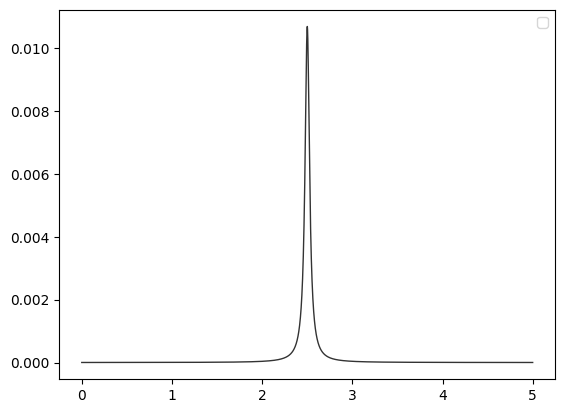

In [135]:
NMRSpectrum.plot_all([mixture], profile=True)

### Estimation

In [136]:
estimation = estimate_proportions(mixture, [component_0, component_1], what_to_compare='area', 
                                      solver=pulp.GUROBI(msg=True),
                                     MTD=0.5, MTD_th=0.5)

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Ubuntu 24.04.1 LTS")

CPU model: 11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 19999 rows, 5003 columns and 54995 nonzeros
Model fingerprint: 0x0d06740f
Coefficient statistics:
  Matrix range     [2e-06, 1e+00]
  Objective range  [2e-06, 1e+00]
  Bounds range     [1e-03, 1e-03]
  RHS range        [1e-03, 1e-01]
Presolve removed 9998 rows and 0 columns
Presolve time: 0.68s
Presolved: 10001 rows, 10001 columns, 44999 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00s

Barrier statistics:
 Dense cols : 2
 AA' NZ     : 5.500e+04
 Factor NZ  : 1.549e+05 (roughly 10 MB of memory)
 Factor Ops : 2.669e+06 (less than 1 second per iteration)
 Threads    : 6

                  Objective                Residual
Iter       P

In [137]:
estimation['proportions']

[np.float64(0.949999999999999), np.float64(0.049999999999999954)]